In [77]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
from scipy.stats import multivariate_normal as normal
import os
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn 
import torch.optim as optim
import torch.nn.functional as F
from torch.nn import Parameter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [2]:
warnings.filterwarnings("ignore")

In [3]:
def read_data(M, select_type='true'):
    df=pd.read_csv('PPDE_simData/GBM_quarticPPDE1.csv').iloc[:,1:]
    df=df[df['type']==select_type].iloc[:M,:-1]
    for i in range(2,11):
        df_temp=pd.read_csv('PPDE_simData/GBM_quarticPPDE'+str(i)+'.csv').iloc[:,1:]
        df_temp=df_temp[df_temp['type']==select_type].iloc[:M,:-1]
        df=pd.concat([df, df_temp])

    res=df.values
    return res

In [4]:
"""
This function defines one block for the nn 
"""
class Dense(nn.Module): 
    def __init__(self,cin, cout, batch_norm=False, activate=True): 
        """
        This class defines a feedforward block which demonstrates the following pipeline: 
        input  --> Batch normalizer (optional) --> Linear Block --> activation function (optional) --> output. 

        cin: input dimension
        cout: output dimension
        batch_norm: True or False
        activate: whether it takes in an activation function
        """
        super(Dense,self).__init__()
        self.cin=cin; 
        self.cout=cout; 
        self.activate=activate; 
        
        self.linear=nn.Linear(self.cin,self.cout) #The linear layer
        #BatchNorm1d: it requires the input to be a correct size
        if batch_norm: 
            self.bn=nn.BatchNorm1d(cout,eps=EPSILON,momentum=MOMENTUM)
        else: 
            self.bn=None
      #  nn.init.normal_(self.linear.weight,std=5.0/np.sqrt(cin+cout))
        # This is the He initialization
        
    def forward(self,x): 
        x=self.linear(x)
        if self.bn is not None:
            x=self.bn(x)
        if self.activate:
            x=torch.relu(x)
        return x 

class FFN(nn.Module):
    def __init__(self, config):
        """
        A Deep fully connected neural network. 
        Config: contains the number of hidden layer shape, example: num_hiddens = [dim,128,128,dim]
        """
        super(FFN,self).__init__()
        self.config=config
        
        self.bn=nn.BatchNorm1d(config.num_hiddens[0],eps=EPSILON,momentum=MOMENTUM) 
        
        self.layers=[Dense(config.num_hiddens[i-1],config.num_hiddens[i]) for i in range(1, len(config.num_hiddens)-1)]
        self.layers+=[Dense(config.num_hiddens[-2], config.num_hiddens[-1],activate=False)]
        self.layers=nn.Sequential(*self.layers)
    
    def forward(self,x):
        x=self.bn(x)
        x=self.layers(x)
        return x 

In [10]:
class Config(object):
    batch_size = 100
    Ntime=101
    
    dim=1; 
    num_hiddens = [dim,64,16,dim] # total two hidden layers
    
def get_config(name):
    try:
        return globals()[name]
    except KeyError:
        raise KeyError("config not defined.")

cfg=get_config('Config')

In [11]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

data_type=torch.float32
MOMENTUM = 0.99
EPSILON = 1e-6

Using mps device


In [12]:
from torch.utils.data import Dataset
from torch.utils.data import TensorDataset, DataLoader

In [13]:
class CustomDataset(Dataset):
    def __init__(self, x_data):
        self.x_data = x_data
        
    def __len__(self):
        return len(self.x_data)
    
    def __getitem__(self, idx):
        return self.x_data[idx]

# Deep Hedging Net

In [14]:
class DeepHedge(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg=cfg
        self.p=Parameter(torch.Tensor([0.0]))
        self.mList=nn.ModuleList([FFN(cfg) for _ in range(self.cfg.Ntime-1)])
        self.K=1.0

    def g_gain(self,x):
        res=0.5*(torch.abs(x-self.K)+x-self.K)
        return res
        

    def loss(self,S):
        """
        S: B x T x C where C=1, T =101
        """
        delta_S=torch.diff(S,axis=1)
        b_size, nstep, c_size=delta_S.shape

        loss_temp=torch.zeros((b_size, c_size))

        for i in range(nstep): 
            loss_temp=loss_temp+ self.mList[i](S[:,i,:])*delta_S[:,i,:]

        loss_temp=torch.mean(torch.sum((loss_temp-self.g_gain(S[:,-1,:])*np.exp(-r)+self.p)**2, axis=-1)) 
        
        return loss_temp

    def get_PnL(self,S):
        """
        S: B x T x C where C=1, T =101 
        """
        delta_S=torch.diff(S,axis=1)
        b_size, nstep, c_size=delta_S.shape

        pnl_temp=torch.zeros((b_size, c_size))

        for i in range(nstep): 
            pnl_temp=pnl_temp+ self.mList[i](S[:,i,:])*delta_S[:,i,:]

        pnl_temp=torch.sum(pnl_temp+self.p, axis=-1) 
        
        return pnl_temp , self.g_gain(S[:,-1,-1])

# True BS Price

In [16]:
import scipy.stats as scipy
from scipy.stats import norm
def BS(S0, strike, T, sigma,r):
    d1=(np.log(S0/strike)+(r+0.5*sigma**2)*T)/(np.sqrt(T)*sigma)
    d2=d1-np.sqrt(T)*sigma
    return S0*scipy.norm.cdf(d1)-np.exp(-r*T)*strike*scipy.norm.cdf(d2)

priceBS=BS(1.0,1.0,1.0,1.0,0.01)
priceBS

np.float64(0.38601243771318305)

## Using the true data

In [17]:
r=0.01
sigma=1.0
T=1.0
N=100
dt=T/N

M=1000

In [22]:
select_type='true'
Xvec=read_data(M ,select_type=select_type)
#Xvec[Xvec<1e-3]
Xvec[Xvec<1e-3]=0.01
Xvec=torch.tensor(Xvec,dtype=torch.float32)
Xvec=Xvec.unsqueeze(-1)

In [23]:
Xvec.shape

torch.Size([10000, 101, 1])

In [24]:
#discount=torch.linspace(0,1,101)
#Xvec=torch.exp(-r*discount.unsqueeze(-1))*Xvec

In [25]:
# Create dataset and dataloader
dataset_true = CustomDataset(Xvec)
dataloader_true = DataLoader(dataset_true, batch_size=cfg.batch_size, shuffle=True)

In [27]:
hedger_true=DeepHedge(cfg)


epochs = 100
grad_clip=0.1

optimizer=optim.Adam(hedger_true.parameters(),lr=5e-4)

pval_true=[]
trainingLoss_true=[]

In [28]:
# Training loop
for epoch in range(epochs):
    # Mini-batch training

    for batch_x in dataloader_true:   
        # Forward pass
        loss = hedger_true.loss(batch_x)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        if grad_clip: 
            nn.utils.clip_grad_value_(hedger_true.parameters(), grad_clip)
        optimizer.step()
    
    if (epoch+1) % 2 == 0:
        pval_true.append(hedger_true.p.item())
        trainingLoss_true.append(loss.item())
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}, pval: {hedger_true.p.item(): .6f}')

Epoch [2/100], Loss: 0.287114, pval:  0.100000
Epoch [4/100], Loss: 0.102790, pval:  0.199999
Epoch [6/100], Loss: 0.103130, pval:  0.298511
Epoch [8/100], Loss: 0.035164, pval:  0.365617
Epoch [10/100], Loss: 0.012678, pval:  0.378244
Epoch [12/100], Loss: 0.047003, pval:  0.379394
Epoch [14/100], Loss: 0.058552, pval:  0.379999
Epoch [16/100], Loss: 0.008509, pval:  0.380750
Epoch [18/100], Loss: 0.075061, pval:  0.383115
Epoch [20/100], Loss: 0.014723, pval:  0.378875
Epoch [22/100], Loss: 0.013128, pval:  0.379656
Epoch [24/100], Loss: 0.016824, pval:  0.381136
Epoch [26/100], Loss: 0.003426, pval:  0.383794
Epoch [28/100], Loss: 0.015114, pval:  0.381026
Epoch [30/100], Loss: 0.010688, pval:  0.379774
Epoch [32/100], Loss: 0.014696, pval:  0.383227
Epoch [34/100], Loss: 0.018894, pval:  0.381742
Epoch [36/100], Loss: 0.009816, pval:  0.381434
Epoch [38/100], Loss: 0.063087, pval:  0.376706
Epoch [40/100], Loss: 0.008413, pval:  0.379724
Epoch [42/100], Loss: 0.008341, pval:  0.382

## Using the VE data

In [30]:
select_type='og'
Xvec=read_data(M ,select_type=select_type)
#Xvec[Xvec<1e-3]
Xvec[Xvec<1e-3]=0.01
Xvec=torch.tensor(Xvec,dtype=torch.float32)
Xvec=Xvec.unsqueeze(-1)

#discount=torch.linspace(0,1,101)
#Xvec=torch.exp(-r*discount.unsqueeze(-1))*Xvec

In [31]:
# Create dataset and dataloader
dataset_true = CustomDataset(Xvec)
dataloader_true = DataLoader(dataset_true, batch_size=cfg.batch_size, shuffle=True)

hedger_og=DeepHedge(cfg)

epochs = 100
grad_clip=0.1

optimizer=optim.Adam(hedger_og.parameters(),lr=5e-4)


pval_ve=[]
trainingLoss_ve=[]

In [32]:
# Training loop
for epoch in range(epochs):
    # Mini-batch training

    for batch_x in dataloader_true:   
        # Forward pass
        loss = hedger_og.loss(batch_x)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        if grad_clip: 
            nn.utils.clip_grad_value_(hedger_og.parameters(), grad_clip)
        optimizer.step()
    
    if (epoch+1) % 2 == 0:
        pval_ve.append(hedger_og.p.item())
        trainingLoss_ve.append(loss.item())
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}, pval: {hedger_og.p.item(): .6f}')

Epoch [2/100], Loss: 0.190010, pval:  0.100000
Epoch [4/100], Loss: 0.082169, pval:  0.199999
Epoch [6/100], Loss: 0.098387, pval:  0.299138
Epoch [8/100], Loss: 0.021871, pval:  0.364239
Epoch [10/100], Loss: 0.010914, pval:  0.378628
Epoch [12/100], Loss: 0.026925, pval:  0.380535
Epoch [14/100], Loss: 0.028255, pval:  0.384801
Epoch [16/100], Loss: 0.015085, pval:  0.383406
Epoch [18/100], Loss: 0.005669, pval:  0.383789
Epoch [20/100], Loss: 0.009602, pval:  0.384786
Epoch [22/100], Loss: 1.347691, pval:  0.384469
Epoch [24/100], Loss: 0.007363, pval:  0.384728
Epoch [26/100], Loss: 0.082870, pval:  0.383597
Epoch [28/100], Loss: 0.007533, pval:  0.380771
Epoch [30/100], Loss: 0.019862, pval:  0.382745
Epoch [32/100], Loss: 0.006118, pval:  0.385514
Epoch [34/100], Loss: 0.010464, pval:  0.385462
Epoch [36/100], Loss: 0.020097, pval:  0.390253
Epoch [38/100], Loss: 0.004654, pval:  0.384895
Epoch [40/100], Loss: 0.007681, pval:  0.384757
Epoch [42/100], Loss: 0.006940, pval:  0.383

In [118]:
select_type='vp'
Xvec=read_data(M ,select_type=select_type)
#Xvec[Xvec<1e-3]
Xvec[Xvec<1e-3]=0.01
Xvec=torch.tensor(Xvec,dtype=torch.float32)
Xvec=Xvec.unsqueeze(-1)

discount=torch.linspace(0,1,101)
Xvec=torch.exp(-r*discount.unsqueeze(-1))*Xvec

In [119]:
# Create dataset and dataloader
dataset_vp = CustomDataset(Xvec)
dataloader_vp = DataLoader(dataset_vp, batch_size=cfg.batch_size, shuffle=True)

hedger_vp=DeepHedge(cfg)

epochs = 100
grad_clip=0.1

optimizer=optim.Adam(hedger_vp.parameters(),lr=5e-4)


pval_vp=[]
trainingLoss_vp=[]

In [120]:
# Training loop
for epoch in range(epochs):
    # Mini-batch training

    for batch_x in dataloader_vp:   
        # Forward pass
        loss = hedger_vp.loss(batch_x)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        if grad_clip: 
            nn.utils.clip_grad_value_(hedger_vp.parameters(), grad_clip)
        optimizer.step()
    
    if (epoch+1) % 2 == 0:
        pval_vp.append(hedger_vp.p.item())
        trainingLoss_vp.append(loss.item())
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}, pval: {hedger_vp.p.item(): .6f}')

Epoch [2/100], Loss: 0.166172, pval:  0.100000
Epoch [4/100], Loss: 0.105470, pval:  0.199999
Epoch [6/100], Loss: 0.024753, pval:  0.299946
Epoch [8/100], Loss: 0.018011, pval:  0.368879
Epoch [10/100], Loss: 0.010666, pval:  0.383403
Epoch [12/100], Loss: 0.017802, pval:  0.385319
Epoch [14/100], Loss: 0.009372, pval:  0.389323
Epoch [16/100], Loss: 0.006686, pval:  0.386934
Epoch [18/100], Loss: 0.020431, pval:  0.386723
Epoch [20/100], Loss: 0.013827, pval:  0.388884
Epoch [22/100], Loss: 0.046209, pval:  0.387299
Epoch [24/100], Loss: 0.009443, pval:  0.381971
Epoch [26/100], Loss: 0.003519, pval:  0.385834
Epoch [28/100], Loss: 0.008968, pval:  0.384266
Epoch [30/100], Loss: 0.004868, pval:  0.384400
Epoch [32/100], Loss: 0.006366, pval:  0.381392
Epoch [34/100], Loss: 0.004752, pval:  0.384237
Epoch [36/100], Loss: 0.002299, pval:  0.384482
Epoch [38/100], Loss: 0.007311, pval:  0.383459
Epoch [40/100], Loss: 0.007071, pval:  0.381642
Epoch [42/100], Loss: 0.004846, pval:  0.382

## Constructing the dataFrame

In [33]:
df_pval=pd.DataFrame(columns=['True_data','Gen'])
df_pval['True_data']=pval_true
df_pval['Gen']=pval_ve

In [34]:
last_num=20
df_pval.iloc[-last_num:].mean(),df_pval.iloc[-last_num:].std()

(True_data    0.379605
 Gen          0.382608
 dtype: float64,
 True_data    0.001392
 Gen          0.001486
 dtype: float64)

In [94]:
#df_pval.to_csv('dh_BSPrice.csv')

# Finding the PnL distribution

In [41]:
discount=torch.linspace(0,1,101)

select_type='true'
Xvec=read_data(M ,select_type=select_type)
#Xvec[Xvec<1e-3]
Xvec[Xvec<1e-3]=0.01
Xvec=torch.tensor(Xvec,dtype=torch.float32)
Xvec=Xvec.unsqueeze(-1)
Xvec_true=Xvec
#Xvec_true=torch.exp(-r*discount.unsqueeze(-1))*Xvec

In [42]:
select_type='og'
Xvec=read_data(M ,select_type=select_type)
#Xvec[Xvec<1e-3]
Xvec[Xvec<1e-3]=0.01
Xvec=torch.tensor(Xvec,dtype=torch.float32)
Xvec=Xvec.unsqueeze(-1)
Xvec_VE=Xvec
#Xvec_VE=torch.exp(-r*discount.unsqueeze(-1))*Xvec

In [43]:
pnl_true,_=hedger_true.get_PnL(Xvec_true)
pnl_ve,_=hedger_og.get_PnL(Xvec_VE)

pnl_true=pnl_true.detach().cpu().numpy()
pnl_ve=pnl_ve.detach().cpu().numpy()

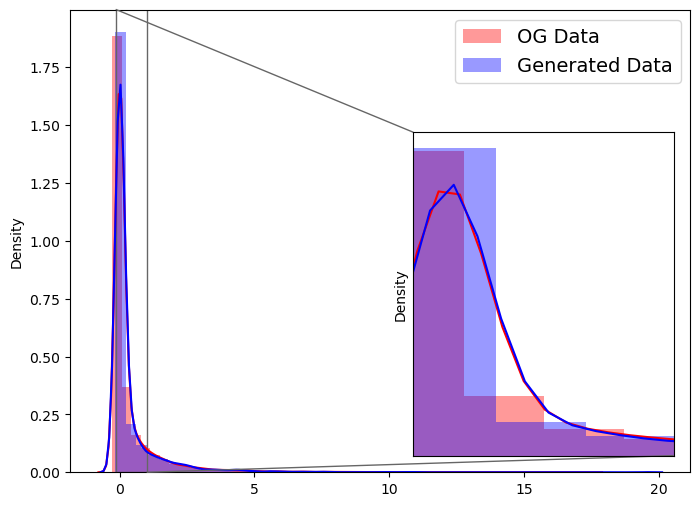

In [87]:
fig, ax = plt.subplots(figsize=(8, 6))

# Main plot
sns.distplot(pnl_true[pnl_true < ub], label="OG Data", color='red', kde=True, ax=ax)
sns.distplot(pnl_ve[pnl_ve < ub], label="Generated Data", color='b', kde=True, ax=ax)
ax.legend(fontsize=14)
ax.set_ylabel("Density")

# Inset: zoom on the spike part
axins = inset_axes(ax, width="42%", height="70%", loc="lower right", borderpad=1.2)
sns.distplot(pnl_true[pnl_true < ub], color='red', kde=True, ax=axins)
sns.distplot(pnl_ve[pnl_ve < ub], color='b', kde=True, ax=axins)

# Adjust these to the spike region you want
axins.set_xlim(-0.15, 1.0)
axins.set_ylim(0.0, 2.0)

axins.set_xticks([])
axins.set_yticks([])

# Draw box and connectors
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4")
plt.savefig('BS/comparison_dh_pnl_VEOG.png')
plt.show()

In [58]:
def summarize_percentiles(data, percentiles=None, decimals=2):
    """
    Calculate and summarize percentiles of a dataset.
    
    Parameters:
    - data: List or array-like, the input data
    - percentiles: List of percentiles to calculate (default: [25, 50, 75, 90, 95, 99])
    - decimals: Number of decimal places to round results (default: 2)
    
    Returns:
    - Dictionary with percentile values and basic statistics
    """
    if percentiles is None:
        percentiles = [1, 5, 25, 50, 75, 90, 99]
    
    
    try:
        data_array = np.array(data)
        valid_data = data_array[~np.isnan(data_array)]
        
        if len(valid_data) == 0:
            return {"error": "No valid numeric data found"}
        
        results = {
          #  "count": len(valid_data),
            "min": round(float(np.min(valid_data)), decimals),
            "max": round(float(np.max(valid_data)), decimals),
            "mean": round(float(np.mean(valid_data)), decimals),
            "std": round(float(np.std(valid_data)), decimals)
        }
        
        # Calculate requested percentiles
        percentile_values = np.percentile(valid_data, percentiles)
        for p, val in zip(percentiles, percentile_values):
            results[f'p{p}'] = round(float(val), decimals)
        
        return results
    
    except Exception as e:
        return {"error": f"An error occurred: {str(e)}"}

In [71]:
df_trueLoc=summarize_percentiles(pnl_true)
df_veLoc=summarize_percentiles(pnl_ve)
#df_vpLoc=summarize_percentiles(pnl_vp)

In [72]:
df=pd.DataFrame()
df=pd.DataFrame(columns=df_trueLoc.keys()).transpose()

In [73]:
df['true']=df_trueLoc.values()
df['generated']=df_veLoc.values()
#df['vp']=df_vpLoc.values()

In [74]:
def save_df_as_image(df, file_path):
    plt.figure(figsize=(8, 6))
    sns.heatmap(df, annot=True, cmap='YlGnBu', fmt='g', cbar=False)
    plt.savefig(file_path, bbox_inches='tight')
    plt.close()

In [75]:
#save_df_as_image(df, 'BS/dh_stats_VEOG.png')